# DeepSky-Classifier — Tableau de bord d'analyse

Restitution des résultats du pipeline de classification d'objets célestes (STAR / GALAXY / QSO).

Ce notebook est **régénérable à la demande** : il lit les artefacts produits par l'entraînement
(`models/run_metadata.json`, `data/raw/sdss/curated_features.parquet`, `reports/figures/`) et ne
recalcule aucune métrique à la main. Tout chiffre affiché ici est donc celui du modèle en service,
relié à son dataset par une empreinte SHA-256.

**Sommaire**

1. Indicateurs clés (KPI)
2. Requêtes SQL d'agrégation sur le jeu curé
3. Profilage des variables (Pandas)
4. Tests statistiques d'hypothèse
5. Visualisations
6. Explicabilité : importance des variables

In [1]:
from base64 import b64encode
from pathlib import Path
import json
import sqlite3

from IPython.display import HTML, Markdown, display
import joblib
import pandas as pd

from src.ml.stats import parallax_mannwhitney, redshift_kruskal

ROOT = Path.cwd()
if not (ROOT / "models").exists():          # tolère une exécution depuis reports/
    ROOT = ROOT.parent


def show_figure(name: str, alt: str) -> None:
    """Affiche une figure avec son texte alternatif : l'information ne doit jamais reposer sur
    la seule perception visuelle (critère d'accessibilité C2.2.1)."""
    data = b64encode((ROOT / "reports" / "figures" / name).read_bytes()).decode()
    display(HTML(f'<img src="data:image/png;base64,{data}" alt="{alt}" style="max-width:100%">'))

METADATA = json.loads((ROOT / "models" / "run_metadata.json").read_text(encoding="utf-8"))
CURATED = pd.read_parquet(ROOT / "data" / "raw" / "sdss" / "curated_features.parquet")
FIGURES = ROOT / "reports" / "figures"

print(f"Jeu curé      : {len(CURATED):,} objets, {CURATED.shape[1]} colonnes")
print(f"Entraîné le   : {METADATA['timestamp']}")
print(f"Dataset SHA   : {METADATA['dataset_sha256'][:16]}...")
print(f"Modèle SHA    : {METADATA['model_sha256'][:16]}...")

Jeu curé      : 6,000 objets, 17 colonnes

Entraîné le   : 2026-07-12T11:12:50.447805+00:00

Dataset SHA   : d39b83bb02df5819...

Modèle SHA    : 7b189ea44a4141f8...

---
## 1. Indicateurs clés

Les trois KPI globaux, lus depuis `run_metadata.json`. Le **F1 macro** est l'indicateur de
référence du projet : il traite chaque classe à égalité et refuse donc de masquer une classe faible
derrière les classes fortes.

In [2]:
m = METADATA["metrics"]

display(Markdown(f"""
| Indicateur | Valeur |
|---|---|
| **Accuracy** | **{m['accuracy']:.4f}** |
| **F1 macro** | **{m['f1_macro']:.4f}** |
| **F1 pondéré** | **{m['f1_weighted']:.4f}** |
| Objets d'entraînement | {METADATA['train_rows']:,} |
| Objets de test | {METADATA['test_rows']:,} |
| Variables | {len(METADATA['feature_columns'])} |
"""))

report = pd.DataFrame(m["classification_report"]).T.loc[METADATA["labels"]]
report[["precision", "recall", "f1-score"]].round(4).style.format(precision=4).background_gradient(
    cmap="Blues", vmin=0.9, vmax=1.0
)


| Indicateur | Valeur |
|---|---|
| **Accuracy** | **0.9833** |
| **F1 macro** | **0.9833** |
| **F1 pondéré** | **0.9833** |
| Objets d'entraînement | 4,800 |
| Objets de test | 1,200 |
| Variables | 8 |


,precision,recall,f1-score
GALAXY,0.9726,0.9775,0.9751
QSO,0.9774,0.9725,0.9749
STAR,1.0000,1.0000,1.0000


### Matrice de confusion

Les erreurs du modèle ne sont pas réparties au hasard : elles se concentrent **exclusivement** sur
la frontière GALAXY / QSO. C'est le comportement attendu — un quasar *est* le noyau actif d'une
galaxie lointaine — alors qu'une étoile se sépare trivialement par son redshift nul.

In [3]:
cm = pd.DataFrame(
    m["confusion_matrix"],
    index=[f"vrai {label}" for label in METADATA["labels"]],
    columns=[f"prédit {label}" for label in METADATA["labels"]],
)
errors = int(cm.to_numpy().sum() - pd.Series(cm.to_numpy().diagonal()).sum())
print(f"{errors} erreurs sur {cm.to_numpy().sum()} objets de test")
cm.style.background_gradient(cmap="Blues")

20 erreurs sur 1200 objets de test

,prédit GALAXY,prédit QSO,prédit STAR
vrai GALAXY,391,9,0
vrai QSO,11,389,0
vrai STAR,0,0,400


---
## 2. Requêtes SQL d'agrégation

Le jeu curé est chargé dans une base SQLite en mémoire (module `sqlite3` de la bibliothèque
standard, aucune dépendance ajoutée), ce qui permet d'interroger les données en SQL plutôt qu'en
Pandas. Les agrégations ci-dessous répondent aux questions de cadrage du plan d'analyse.

In [4]:
conn = sqlite3.connect(":memory:")
CURATED.to_sql("objects", conn, index=False)

def q(sql: str) -> pd.DataFrame:
    """Exécute une requête SQL sur le jeu curé et renvoie le résultat."""
    return pd.read_sql_query(sql, conn)

q("""
    SELECT
        class_label                        AS classe,
        COUNT(*)                           AS effectif,
        ROUND(AVG(redshift), 4)            AS redshift_moyen,
        ROUND(MIN(redshift), 4)            AS redshift_min,
        ROUND(MAX(redshift), 4)            AS redshift_max
    FROM objects
    GROUP BY class_label
    ORDER BY redshift_moyen
""")

,classe,effectif,redshift_moyen,redshift_min,redshift_max
0,STAR,2000,-0.0001,-0.0036,0.0033
1,GALAXY,2000,0.3877,-0.0001,1.4758
2,QSO,2000,1.6500,0.0629,7.0131


La lecture est immédiate et physiquement cohérente : les étoiles sont à redshift nul (elles
appartiennent à notre galaxie), les galaxies à redshift modéré, les quasars — bien plus lointains —
à redshift élevé. Les plages de GALAXY et QSO **se recouvrent**, ce qui est le signe d'un
échantillon représentatif.

### Couverture du cross-match Gaia

Cette requête révèle le résultat le plus contre-intuitif du projet : la disponibilité d'une
solution astrométrique Gaia dépend fortement de la classe.

In [5]:
q("""
    SELECT
        class_label                                            AS classe,
        COUNT(*)                                               AS total,
        SUM(CASE WHEN gaia_source_id IS NOT NULL THEN 1 ELSE 0 END)  AS apparies_gaia,
        SUM(CASE WHEN gaia_parallax  IS NOT NULL THEN 1 ELSE 0 END)  AS avec_astrometrie,
        ROUND(100.0 * SUM(CASE WHEN gaia_parallax IS NOT NULL THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN gaia_source_id IS NOT NULL THEN 1 ELSE 0 END), 0), 1)
                                                               AS pct_astrometrie
    FROM objects
    GROUP BY class_label
    ORDER BY pct_astrometrie DESC
""")

,classe,total,apparies_gaia,avec_astrometrie,pct_astrometrie
0,STAR,2000,1895,1832,96.7
1,QSO,2000,1279,1045,81.7
2,GALAXY,2000,675,68,10.1


**Seules 10 % des galaxies appariées possèdent une parallaxe, contre 97 % des étoiles.**

Gaia ne résout une solution astrométrique complète que pour les sources qu'il perçoit comme
ponctuelles et suffisamment brillantes, ce que les objets extragalactiques ne sont généralement pas.
Autrement dit : **l'absence de parallaxe est elle-même un indice fort que la source est
extragalactique**. Une version antérieure du pipeline filtrait ces lignes (`WHERE parallax IS NOT
NULL`), croyant écarter des données manquantes ; elle supprimait en réalité 90 % des galaxies et
jetait le signal recherché. Ces lignes sont désormais conservées, et l'information d'absence est
transmise au modèle via la variable `gaia_has_astrometry`.

---
## 3. Profilage des variables

Le profilage Pandas complète les agrégations SQL. C'est ce contrôle qui a permis de détecter un
défaut d'échantillonnage majeur : sur une version antérieure du jeu, l'écart-type du redshift des
galaxies valait 0,003, une valeur physiquement absurde qui trahissait un tirage non représentatif.

In [6]:
profil = CURATED.groupby("class_label")["redshift"].agg(["count", "mean", "std", "median", "max"])
display(profil.round(4))

magnitudes = CURATED.groupby("class_label")[["u", "g", "r", "i", "z_mag"]].mean()
display(magnitudes.round(3).style.background_gradient(cmap="Blues", axis=1))

,count,mean,std,median,max
class_label,,,,,
GALAXY,2000,0.3877,0.2743,0.3804,1.4758
QSO,2000,1.6500,0.7774,1.6037,7.0131
STAR,2000,-0.0001,0.0004,-0.0001,0.0033


,u,g,r,i,z_mag
class_label,,,,,
GALAXY,22.155000,20.543000,19.332000,18.687000,18.315000
QSO,21.264000,20.765000,20.509000,20.335000,20.194000
STAR,20.391000,18.874000,18.199000,17.842000,17.651000


Les quasars présentent un profil de magnitudes quasi plat (de 20,77 en `g` à 20,19 en `z_mag`), là
où galaxies et étoiles s'éclaircissent nettement vers l'infrarouge. C'est cette différence de
*couleur* — l'écart entre bandes, et non la magnitude absolue — que le modèle exploite lorsque le
redshift lui est retiré.

---
## 4. Tests statistiques d'hypothèse

Deux hypothèses physiques sont testées, avec des tests **non paramétriques** : les distributions
astronomiques sont fortement asymétriques et comportent des valeurs extrêmes, ce qui disqualifie
l'ANOVA et le test *t*.

- **H1** — la distribution du redshift diffère entre les trois classes → *Kruskal-Wallis*
- **H2** — la parallaxe Gaia sépare les étoiles des objets extragalactiques → *Mann-Whitney*

In [7]:
kruskal = redshift_kruskal(CURATED)
mann = parallax_mannwhitney(CURATED)

def p_str(res: dict) -> str:
    """Une p-value peut dépasser la précision du flottant 64 bits : on rapporte alors la borne."""
    return "< 5e-324 (underflow)" if res["p_value_underflow"] else f"{res['p_value']:.3e}"

display(Markdown(f"""
| Test | Statistique | p-value | Effectifs | Décision (α = 0,05) |
|---|---|---|---|---|
| Kruskal-Wallis sur `redshift` | H = {kruskal['statistic']:,.2f} | {p_str(kruskal)} | {kruskal['n_groups']} groupes | **{'H₀ rejetée' if kruskal['reject_null'] else 'H₀ conservée'}** |
| Mann-Whitney sur `gaia_parallax` | U = {mann['statistic']:,.0f} | {p_str(mann)} | {mann['n_stars']:,} étoiles / {mann['n_extragalactic']:,} extragal. | **{'H₀ rejetée' if mann['reject_null'] else 'H₀ conservée'}** |
"""))

[2026-07-12 14:01:24]

 [

INFO    

] [

src.ml.stats

...

INFO    

] [

src.ml.stats

         ] Mann-Whitney on gaia_parallax: U=1579134.0000, p=4.44224e-138



| Test | Statistique | p-value | Effectifs | Décision (α = 0,05) |
|---|---|---|---|---|
| Kruskal-Wallis sur `redshift` | H = 5,082.62 | < 5e-324 (underflow) | 3 groupes | **H₀ rejetée** |
| Mann-Whitney sur `gaia_parallax` | U = 1,579,134 | 4.442e-138 | 1,832 étoiles / 1,113 extragal. | **H₀ rejetée** |


Les deux hypothèses sont validées de façon massive.

Une remarque sur la p-value du Kruskal-Wallis : SciPy renvoie exactement `0.0`. Ce n'est pas une
p-value nulle mais un **dépassement de capacité du flottant 64 bits** — la valeur réelle est
inférieure au plus petit flottant positif représentable (5 × 10⁻³²⁴). Un test ne borne jamais la
p-value que par le haut, donc écrire « p = 0 » serait un abus de langage. Le code expose un
indicateur `p_value_underflow` pour que le chiffre reporté reste défendable.

---
## 5. Visualisations

Les trois figures sont régénérées à chaque entraînement par `src/ml/plots.py`.


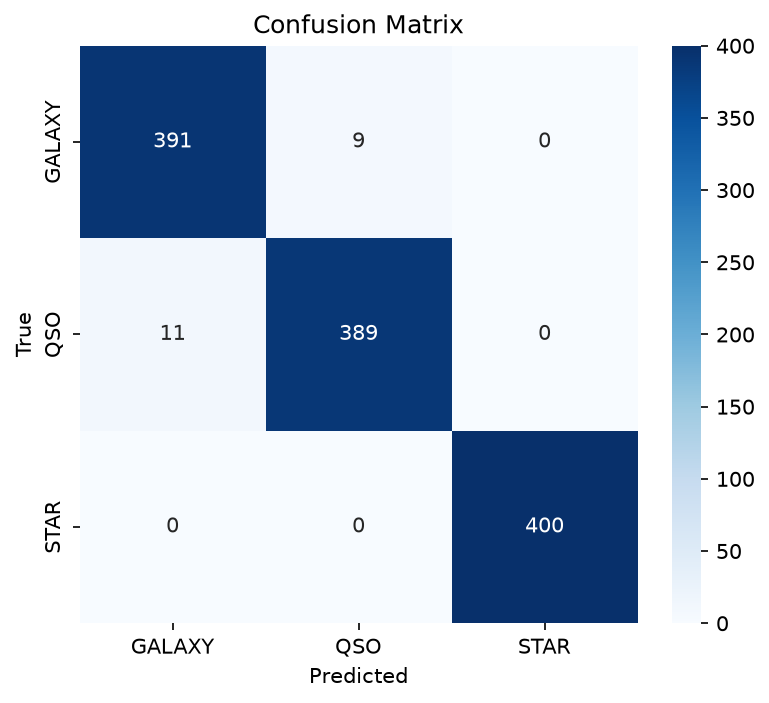

In [8]:
show_figure(
    "confusion_matrix.png",
    "Matrice de confusion : 391 galaxies et 389 quasars correctement classés, 400 étoiles sur 400. "
    "Les 20 erreurs sont exclusivement des confusions entre galaxies et quasars ; aucune étoile "
    "n'est confondue avec un objet extragalactique.",
)


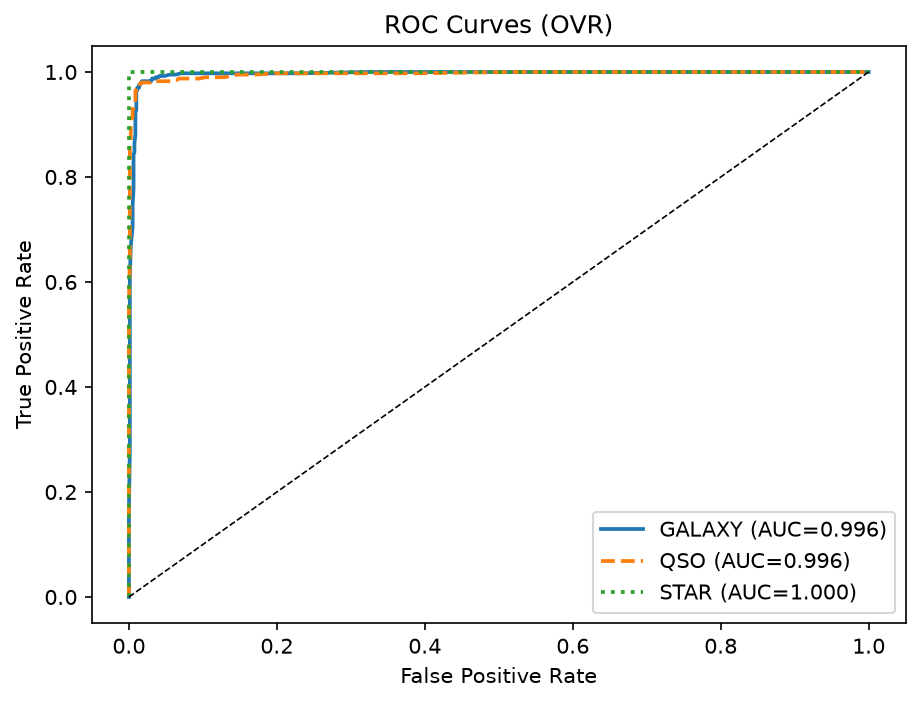

In [9]:
show_figure(
    "roc_curves.png",
    "Courbes ROC One-versus-Rest. AUC de 0,996 pour GALAXY (trait continu), 0,996 pour QSO "
    "(tirets) et 1,000 pour STAR (pointillés). Les trois courbes montent quasi verticalement "
    "vers le coin supérieur gauche, très au-dessus de la diagonale de référence aléatoire.",
)

Les courbes ROC cyclent un **style de trait par classe** (continu, tirets, pointillés) et pas
seulement une teinte : la figure reste lisible en niveaux de gris et pour un lecteur atteint d'une
déficience de la vision des couleurs. L'AUC figure dans la légende, donc l'information chiffrée
accompagne toujours la courbe.

Les AUC quasi maximales (0,996) malgré les confusions GALAXY ↔ QSO montrent que le modèle *ordonne*
correctement ces objets par probabilité : les erreurs se concentrent près du seuil de décision, pas
dans les cas nets. C'est ce qui rend viable un seuil de confiance en production.


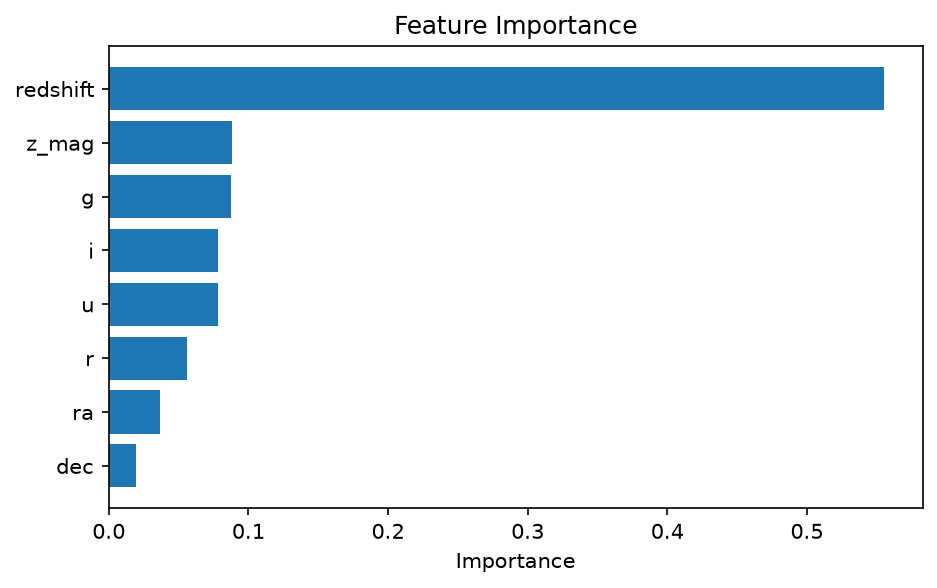

In [10]:
show_figure(
    "feature_importance.png",
    "Importance des variables du Random Forest, en barres horizontales triées. Le redshift domine "
    "très largement avec 0,555, suivi des cinq magnitudes optiques regroupées entre 0,056 et 0,088. "
    "Les coordonnées ra et dec ferment la marche avec 0,037 et 0,020.",
)

---
## 6. Explicabilité : importance des variables

In [11]:
model = joblib.load(ROOT / "models" / "rf_classifier.joblib")
importances = (
    pd.DataFrame(
        {"variable": METADATA["feature_columns"], "importance": model.feature_importances_}
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importances.style.format({"importance": "{:.4f}"}).bar(
    subset=["importance"], color="#4a7fb5", vmin=0
)

,variable,importance
0,redshift,0.5550
1,z_mag,0.0879
2,g,0.0875
3,i,0.0785
4,u,0.0783
5,r,0.0561
6,ra,0.0369
7,dec,0.0198


Le `redshift` porte à lui seul **55 % de la décision**, ce qui rejoint directement le test de
Kruskal-Wallis. Les cinq magnitudes optiques se partagent l'essentiel du reste, de façon
remarquablement homogène : aucune bande n'est décisive isolément, c'est leur combinaison qui
informe.

Les coordonnées `ra` et `dec` ferment la marche, ce qui est rassurant : la position dans le ciel ne
devrait porter aucune information de classe.

### Conséquence : quand l'enrichissement Gaia sert-il vraiment ?

Le redshift est une mesure **spectroscopique**, donc coûteuse : elle exige un spectre. Il sature à
lui seul le problème (F1 macro de 0,90 en solo), ce qui masque totalement l'apport de Gaia. Mais dès
qu'on le retire, pour se placer dans le régime des grands relevés d'imagerie, Gaia devient décisif :

| Jeu de variables | F1 macro (CV 5 plis) |
|---|---|
| Photométrie seule | 0,8601 |
| **Photométrie + Gaia** | **0,9131** *(+0,053)* |
| Photométrie + redshift | 0,9760 |
| Photométrie + redshift + Gaia | 0,9775 *(+0,0015, dans le bruit)* |

**Recommandation** : activer l'enrichissement Gaia si et seulement si le redshift spectroscopique
n'est pas disponible. C'est précisément le cas d'usage des futurs grands relevés photométriques.